# Axis-shortedge 4인자 DOE 50점 분석

이 노트북은 FEMM 해석 결과 50점을 다음 두 목적함수로 분석한다.

- **평균토크 최대화**
- **절대 토크리플(pk-pk) 최소화**

## 먼저 보는 결론

- **종합 균형 설계: Run 49** — 평균토크 46.76 Nm, 리플 4.69 Nm, 리플률 10.04%
- **토크를 조금 더 중시: Run 42** — 평균토크 47.94 Nm, 리플 5.15 Nm
- **최저 리플: Run 14** — 평균토크 38.66 Nm, 리플 3.05 Nm
- **최대 평균토크: Run 27** — 평균토크 51.07 Nm, 리플 10.60 Nm

이번 결과에서도 평균토크와 리플 사이에 강제적인 트레이드오프는 없다.  
특히 긴 자석으로 평균토크를 확보하고 큰 V각으로 파형을 평탄화한 Run 49가 두 목표를 동시에 잘 만족한다.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", message="Glyph .* missing")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["axes.unicode_minus"] = False
pd.options.display.float_format = "{:.4f}".format

ROOT = Path.cwd()
if not (ROOT / "doe_axis_shortedge_results").exists():
    ROOT = Path("C:/Users/139/Documents/pyFEMM 2")

RESULT_DIR = ROOT / "doe_axis_shortedge_results"
SUMMARY_CSV = RESULT_DIR / "axis_shortedge_ccf_summary.csv"
df = pd.read_csv(SUMMARY_CSV)

factors = [
    "magnet_thickness_mm",
    "magnet_length_mm",
    "v_angle_deg",
    "tip_gap_mm",
]
factor_labels = ["Thickness", "Length", "V angle", "TIPGAP"]
mean_col = "loaded_torque_mean_Nm"
ripple_col = "loaded_torque_pkpk_Nm"
ripple_pct_col = "loaded_torque_ripple_pct"

print(f"Summary rows: {len(df)}")
print(f"Completed points per design: {sorted(df['completed_points'].unique())}")
print(f"Angle sweep: {df.theta_start_deg.iloc[0]:g}–{df.theta_stop_deg.iloc[0]:g} deg, "
      f"step {df.theta_step_deg.iloc[0]:g} deg")
print(f"Current peak: {df.current_peak_A.iloc[0]:g} A, "
      f"commutation offset: {df.commutation_offset_deg.iloc[0]:g} deg")

Summary rows: 50
Completed points per design: [np.int64(15)]
Angle sweep: 0–28 deg, step 2 deg
Current peak: 10 A, commutation offset: 35 deg


## 1. 데이터 완전성

모든 Run 폴더에 15개 회전자 각도 결과가 있는지 확인한다. 하나라도 누락되면 아래 셀이 오류를 발생시킨다.

In [2]:
integrity = []
for run in df["run"].astype(int):
    sweep_path = RESULT_DIR / f"run_{run:03d}" / "axis_shortedge_loaded_sweep.csv"
    n_rows = len(pd.read_csv(sweep_path)) if sweep_path.exists() else 0
    integrity.append({"run": run, "sweep_rows": n_rows, "status": "OK" if n_rows == 15 else "CHECK"})

integrity_df = pd.DataFrame(integrity)
display(integrity_df["status"].value_counts().rename_axis("status").to_frame("design_count"))
assert len(df) == 50 and (integrity_df["sweep_rows"] == 15).all()
print("검증 통과: 50개 설계 × 15개 각도 = 750개 FEMM 운전점")

,design_count
status,
OK,50


검증 통과: 50개 설계 × 15개 각도 = 750개 FEMM 운전점


## 2. 성능 순위

In [3]:
show_cols = factors + [mean_col, ripple_col, ripple_pct_col]
rename = {
    "magnet_thickness_mm": "Thickness [mm]",
    "magnet_length_mm": "Length [mm]",
    "v_angle_deg": "V angle [deg]",
    "tip_gap_mm": "TIPGAP [mm]",
    mean_col: "Mean torque [Nm]",
    ripple_col: "Ripple pk-pk [Nm]",
    ripple_pct_col: "Ripple [%]",
}

print("평균토크 상위 10개")
display(df.set_index("run").sort_values(mean_col, ascending=False)[show_cols].head(10).rename(columns=rename))

print("절대 리플 하위 10개")
display(df.set_index("run").sort_values(ripple_col)[show_cols].head(10).rename(columns=rename))

평균토크 상위 10개


,Thickness [mm],Length [mm],V angle [deg],TIPGAP [mm],Mean torque [Nm],Ripple pk-pk [Nm],Ripple [%]
run,,,,,,,
27,5.4498,15.1776,73.9672,0.7877,51.0658,10.5968,20.7513
25,4.6584,16.5892,59.2640,4.2548,48.3330,8.7140,18.0290
7,4.3306,15.5723,60.9155,1.5857,48.2178,14.6074,30.2947
42,4.1286,16.7881,73.2371,2.6631,47.9405,5.1456,10.7333
44,5.2522,14.9867,74.9446,1.7763,47.8647,7.6107,15.9004
49,4.8377,15.9807,85.8621,0.7314,46.7562,4.6941,10.0395
29,3.8452,15.3601,66.2971,1.0785,46.4214,11.0163,23.7311
45,4.9009,14.7329,63.6426,2.2030,46.3333,13.1051,28.2845
23,3.5617,15.4956,59.3579,2.1658,43.0649,12.3742,28.7338


절대 리플 하위 10개


,Thickness [mm],Length [mm],V angle [deg],TIPGAP [mm],Mean torque [Nm],Ripple pk-pk [Nm],Ripple [%]
run,,,,,,,
14,2.8672,16.1017,86.9920,1.1213,38.6614,3.0458,7.8782
17,2.9240,15.3121,82.5676,3.6798,34.2602,4.2176,12.3106
49,4.8377,15.9807,85.8621,0.7314,46.7562,4.6941,10.0395
43,3.9991,14.0431,89.7589,0.7401,37.5613,4.7408,12.6215
42,4.1286,16.7881,73.2371,2.6631,47.9405,5.1456,10.7333
1,2.5623,13.6902,83.4436,2.6975,29.1981,5.2165,17.8658
30,3.4545,12.0737,39.4017,1.6308,13.0108,5.3847,41.3864
40,4.0356,14.5803,78.2986,2.5128,40.5350,5.5680,13.7363
48,3.0853,12.5968,89.5807,0.8382,28.7159,5.6194,19.5689


## 3. 파레토 프론트

다른 설계보다 평균토크가 낮으면서 리플도 큰 점은 지배된 설계다.  
아래 빨간 점은 어떤 다른 설계에도 두 목적을 동시에 지배당하지 않는 파레토 설계다.

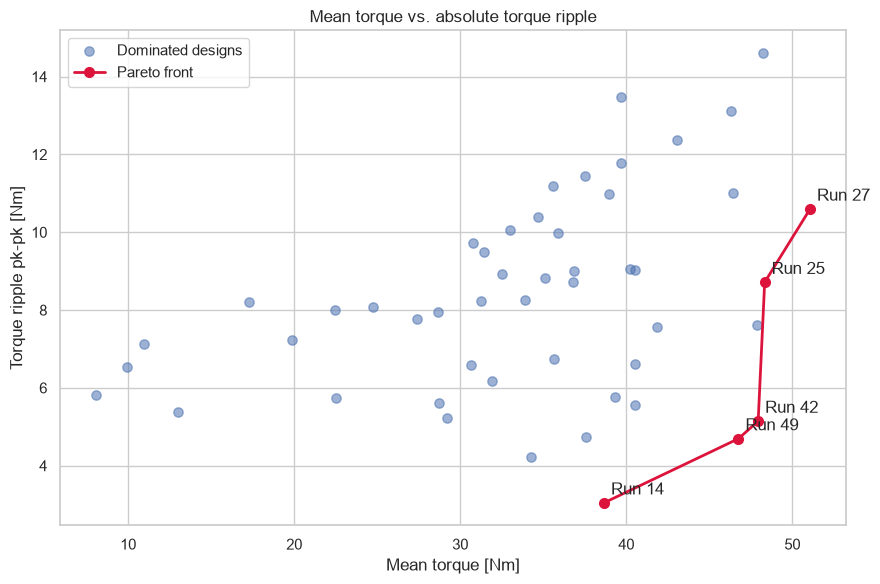

,Thickness [mm],Length [mm],V angle [deg],TIPGAP [mm],Mean torque [Nm],Ripple pk-pk [Nm],Ripple [%]
run,,,,,,,
14,2.8672,16.1017,86.9920,1.1213,38.6614,3.0458,7.8782
49,4.8377,15.9807,85.8621,0.7314,46.7562,4.6941,10.0395
42,4.1286,16.7881,73.2371,2.6631,47.9405,5.1456,10.7333
25,4.6584,16.5892,59.2640,4.2548,48.3330,8.7140,18.0290
27,5.4498,15.1776,73.9672,0.7877,51.0658,10.5968,20.7513


In [4]:
def pareto_mask(frame):
    mean = frame[mean_col].to_numpy()
    ripple = frame[ripple_col].to_numpy()
    keep = np.ones(len(frame), dtype=bool)
    for i in range(len(frame)):
        dominates_i = (
            (mean >= mean[i])
            & (ripple <= ripple[i])
            & ((mean > mean[i]) | (ripple < ripple[i]))
        )
        keep[i] = not dominates_i.any()
    return keep

df["pareto"] = pareto_mask(df)
pareto = df[df["pareto"]].sort_values(mean_col)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df.loc[~df.pareto, mean_col], df.loc[~df.pareto, ripple_col],
           s=45, alpha=0.55, label="Dominated designs")
ax.plot(pareto[mean_col], pareto[ripple_col], "-o", color="crimson",
        lw=2, ms=7, label="Pareto front")
for _, row in pareto.iterrows():
    ax.annotate(f"Run {int(row.run)}", (row[mean_col], row[ripple_col]),
                xytext=(5, 6), textcoords="offset points")
ax.set(xlabel="Mean torque [Nm]", ylabel="Torque ripple pk-pk [Nm]",
       title="Mean torque vs. absolute torque ripple")
ax.legend()
plt.tight_layout()
plt.show()

display(pareto.set_index("run")[show_cols].rename(columns=rename))

### 파레토 해석

- **Run 14:** 리플 최소가 최우선일 때
- **Run 49:** 높은 평균토크와 낮은 리플을 동시에 잡은 종합 균형점
- **Run 42:** Run 49보다 평균토크를 약 1.18 Nm 더 얻고 리플을 약 0.45 Nm 허용
- **Run 25:** 평균토크 우선
- **Run 27:** 평균토크 최대점

## 4. 단순 상관관계

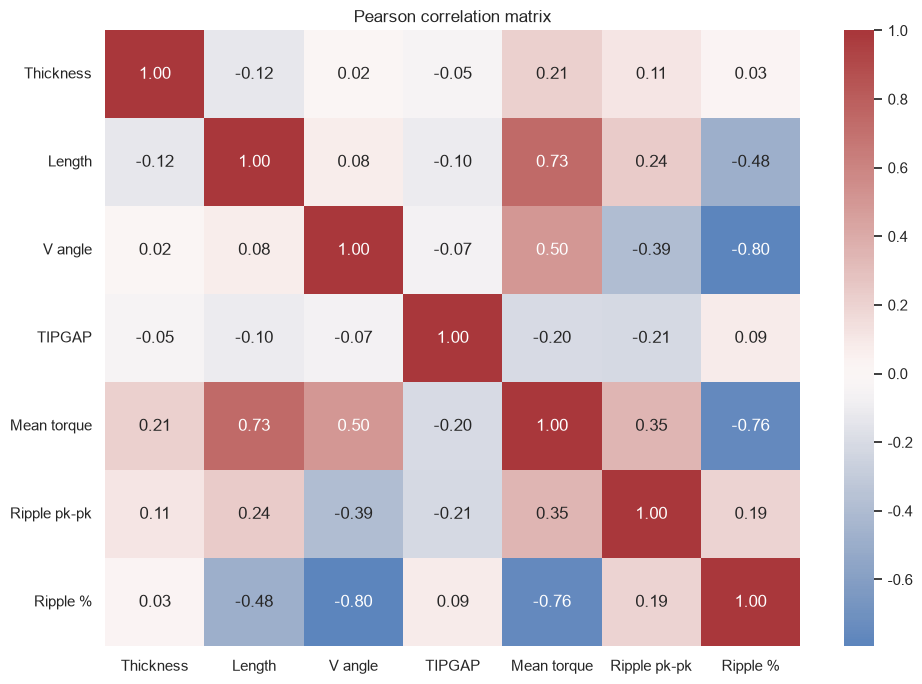

평균토크–절대리플 상관계수: 0.347


In [5]:
corr_cols = factors + [mean_col, ripple_col, ripple_pct_col]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            xticklabels=factor_labels + ["Mean torque", "Ripple pk-pk", "Ripple %"],
            yticklabels=factor_labels + ["Mean torque", "Ripple pk-pk", "Ripple %"],
            ax=ax)
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

print(f"평균토크–절대리플 상관계수: {df[mean_col].corr(df[ripple_col]):.3f}")

단순 상관계수만 보면:

- **Length**가 평균토크와 가장 강한 양의 관계를 가진다.
- 큰 **V angle**은 절대 리플, 특히 리플률 감소와 관계가 크다.
- 평균토크와 절대 리플의 상관은 약 0.35로 약하다. 따라서 높은 토크가 반드시 큰 리플을 뜻하지 않는다.

단, 형상 효과는 비선형이고 변수끼리 상호작용하므로 아래 2차 모델을 함께 봐야 한다.

## 5. 2차 반응표면과 변수 민감도

,Mean torque model,Ripple model
Training R2,0.9956,0.8641
CV R2,0.9897,0.7684
Training RMSE,0.6847,0.9389
CV RMSE,1.0414,1.2257


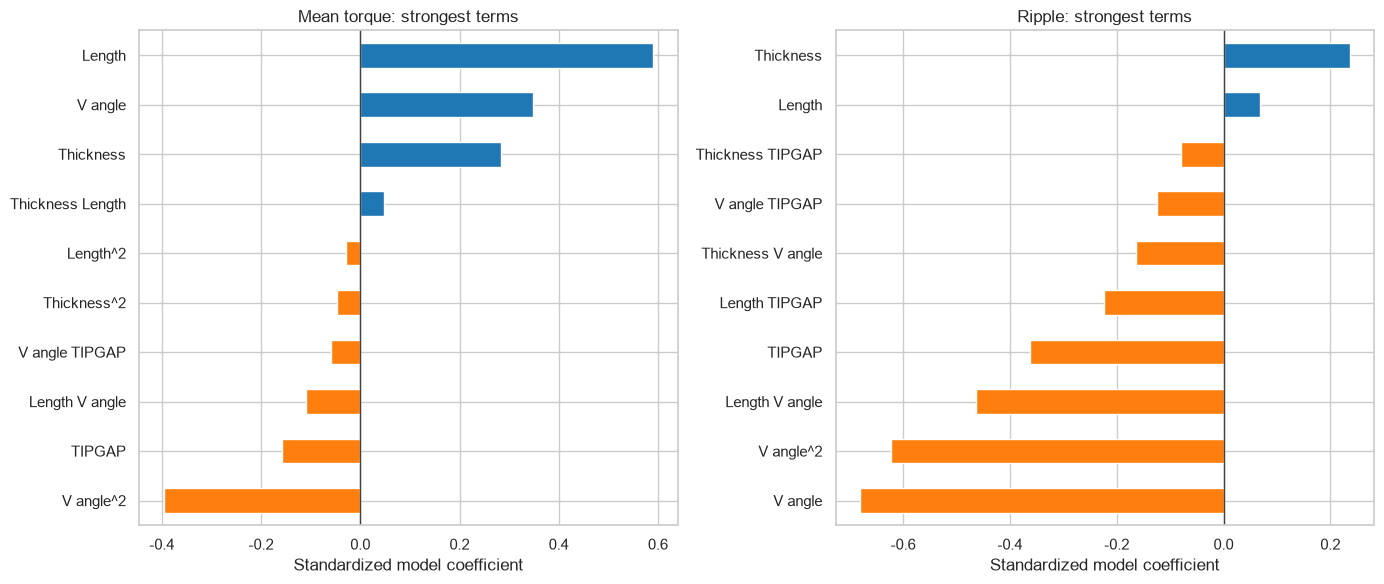

In [6]:
X = df[factors]
cv = KFold(n_splits=5, shuffle=True, random_state=123)

def fit_quadratic(target):
    model = Pipeline([
        ("scale_x", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("reg", LinearRegression()),
    ])
    wrapped = TransformedTargetRegressor(regressor=model, transformer=StandardScaler())
    y = df[target].to_numpy()
    pred_cv = cross_val_predict(wrapped, X, y, cv=cv)
    wrapped.fit(X, y)
    fitted = wrapped.predict(X)
    metrics = {
        "Training R2": r2_score(y, fitted),
        "CV R2": r2_score(y, pred_cv),
        "Training RMSE": root_mean_squared_error(y, fitted),
        "CV RMSE": root_mean_squared_error(y, pred_cv),
    }
    inner = wrapped.regressor_
    terms = inner.named_steps["poly"].get_feature_names_out(factor_labels)
    coef = inner.named_steps["reg"].coef_
    effects = pd.Series(coef, index=terms).sort_values(key=np.abs, ascending=False)
    return wrapped, metrics, effects

mean_model, mean_metrics, mean_effects = fit_quadratic(mean_col)
ripple_model, ripple_metrics, ripple_effects = fit_quadratic(ripple_col)

metrics_df = pd.DataFrame(
    {"Mean torque model": mean_metrics, "Ripple model": ripple_metrics}
)
display(metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, effects, title in [
    (axes[0], mean_effects.head(10).sort_values(), "Mean torque: strongest terms"),
    (axes[1], ripple_effects.head(10).sort_values(), "Ripple: strongest terms"),
]:
    colors = ["tab:blue" if value >= 0 else "tab:orange" for value in effects]
    effects.plot.barh(ax=ax, color=colors)
    ax.axvline(0, color="0.25", lw=1)
    ax.set_xlabel("Standardized model coefficient")
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 민감도 해석

- 평균토크 모델은 교차검증에서도 매우 잘 맞는다(`CV R² ≈ 0.99`). **Length가 가장 강하고**, V angle, Thickness 순으로 중요하다.
- V angle에는 큰 음의 제곱항이 있어 각도를 무조건 90°까지 키우는 것이 평균토크 최대 조건은 아니다.
- 리플 모델은 평균토크보다 불확실하다(`CV R² ≈ 0.74`). **V angle의 선형·제곱 효과와 Length×V angle 상호작용**이 핵심이다.
- 따라서 예전 Run 308처럼 높은 토크와 낮은 리플이 동시에 나타난 것은 오류라기보다, Length로 토크를 확보하고 각도 및 다른 변수로 리플을 상쇄한 결과일 가능성이 높다.

## 6. 파레토 설계의 실제 토크 파형

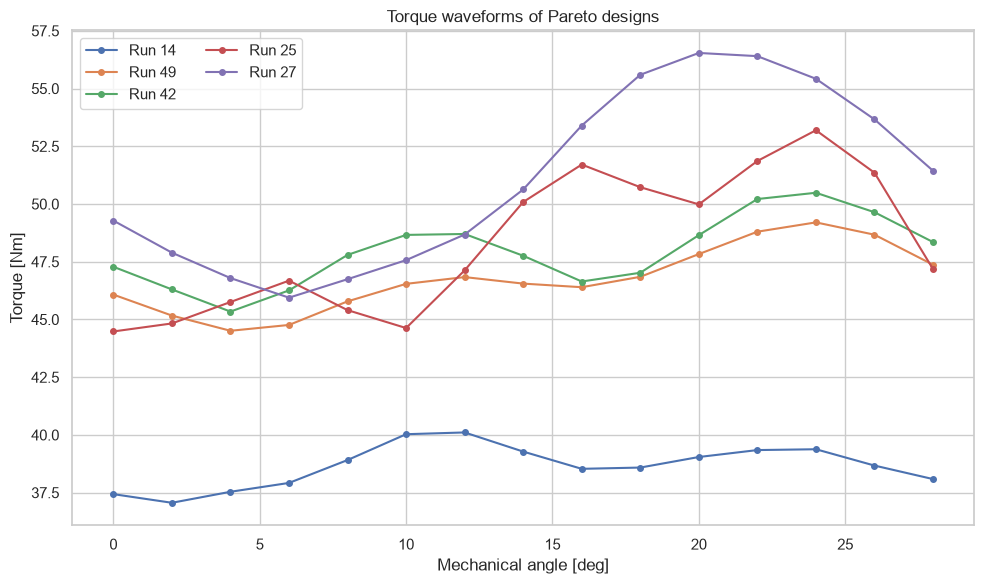

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for run in pareto["run"].astype(int):
    sweep = pd.read_csv(
        RESULT_DIR / f"run_{run:03d}" / "axis_shortedge_loaded_sweep.csv"
    )
    ax.plot(sweep["theta_deg"], sweep["torque_Nm"], marker="o", ms=4,
            label=f"Run {run}")
ax.set(xlabel="Mechanical angle [deg]", ylabel="Torque [Nm]",
       title="Torque waveforms of Pareto designs")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## 7. 다음 해석 권장사항

현재 결과는 모든 설계에 공통으로 다음 조건을 적용했다.

- 회전자 기계 초기각: -10°
- 전류 피크: 10 A
- Commutation offset: 35°
- 회전자 각도: 0–28°, 2° 간격

따라서 설계 비교용으로는 일관되지만 두 가지 오차 가능성이 있다.

1. **2° 샘플링이 실제 최대·최소 토크를 놓칠 수 있다.**  
   Run 42와 49의 리플 차이는 작아서 0.5° 재해석 시 순위가 바뀔 수 있다.
2. **설계별 최적 commutation offset이 다를 수 있다.**  
   공통 35°는 공정한 고정 제어조건이지만 각 설계의 개별 최대 성능은 아니다.

### 권장 후속 순서

1. Run **14, 42, 49**를 0–30°, 0.5° 간격으로 재해석
2. 위 세 설계에서 commutation offset 30–40° 탐색
3. 확인된 최종 값으로 Run 42와 Run 49 중 기준 형상 선정
4. 선정점 주변에서 범위를 좁힌 2차 DOE 또는 NSGA-II 수행

# 8. DNN surrogate 기반 1,000개 설계 탐색

아래부터는 동일한 FEMM 50점 결과로 DNN surrogate를 학습하고,
형상검사를 통과한 신규 1,000개 설계를 예측한 분석이다.

> 1,000개 결과는 DNN 예측값이며 FEMM 해석값이 아니다.
> 최종 후보는 반드시 FEMM으로 다시 검증해야 한다.

In [8]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import qmc
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from generate_axis_shortedge_doe_previews import RANGES, evaluate_row

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Glyph .* missing")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5.5)
pd.options.display.float_format = "{:.4f}".format

ROOT = Path.cwd()
if not (ROOT / "doe_axis_shortedge_results").exists():
    ROOT = Path("C:/Users/139/Documents/pyFEMM 2")
RESULT_DIR = ROOT / "doe_axis_shortedge_results"
SUMMARY_CSV = RESULT_DIR / "axis_shortedge_ccf_summary.csv"

df = pd.read_csv(SUMMARY_CSV)
factors = ["magnet_thickness_mm", "magnet_length_mm", "v_angle_deg", "tip_gap_mm"]
factor_labels = ["Thickness", "Length", "V angle", "TIPGAP"]
targets = ["loaded_torque_mean_Nm", "loaded_torque_pkpk_Nm"]
X = df[factors].to_numpy()
y = df[targets].to_numpy()

print(f"Training designs: {len(df)}")
display(df[factors + targets].describe().T)

Training designs: 50


,count,mean,std,min,25%,50%,75%,max
magnet_thickness_mm,50.0000,3.8938,0.8209,2.5139,3.2117,3.9280,4.5764,5.4498
magnet_length_mm,50.0000,14.1091,1.4705,12.0737,12.8450,14.0197,15.2785,16.7881
v_angle_deg,50.0000,63.2763,15.8806,35.6190,51.1816,63.1099,75.9667,89.7589
tip_gap_mm,50.0000,2.4037,1.2638,0.5108,1.2866,2.3600,3.6238,4.4628
loaded_torque_mean_Nm,50.0000,34.0774,10.3803,8.0698,29.5616,35.6127,40.4354,51.0658
loaded_torque_pkpk_Nm,50.0000,8.2417,2.5730,3.0458,6.2725,8.1359,9.9113,14.6074


## 1. DNN 구조와 반복 교차검증

- 입력: Thickness, Length, V angle, TIPGAP
- 출력: 평균토크, 토크리플 pk-pk
- 은닉층: 32–16–8, `tanh`
- 정규화: 입력과 출력 모두 표준화
- 검증: 5-fold × 5회 반복

50점에서 과도하게 큰 네트워크를 쓰면 학습점을 외우기 쉬우므로 L2 규제를 적용했다.

,CV R2,CV RMSE
Mean torque [Nm],0.9619,2.0064
Ripple pk-pk [Nm],0.8815,0.8767


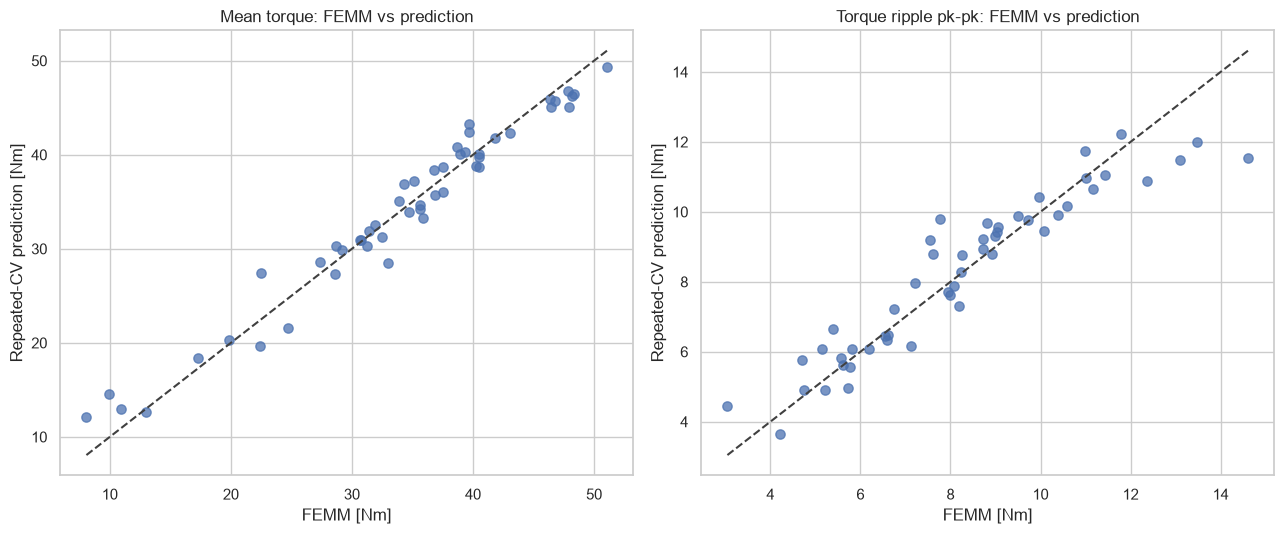

In [9]:
def make_model(seed):
    network = Pipeline([
        ("scale_x", StandardScaler()),
        ("dnn", MLPRegressor(
            hidden_layer_sizes=(32, 16, 8),
            activation="tanh",
            solver="lbfgs",
            alpha=1.0,
            max_iter=4000,
            random_state=seed,
        )),
    ])
    return TransformedTargetRegressor(regressor=network, transformer=StandardScaler())

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=20260730)
pred_sum = np.zeros_like(y, dtype=float)
pred_count = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    model = make_model(1000 + fold)
    model.fit(X[train_idx], y[train_idx])
    pred_sum[test_idx] += model.predict(X[test_idx])
    pred_count[test_idx] += 1

cv_pred = pred_sum / pred_count[:, None]
metrics = pd.DataFrame({
    "CV R2": [
        r2_score(y[:, 0], cv_pred[:, 0]),
        r2_score(y[:, 1], cv_pred[:, 1]),
    ],
    "CV RMSE": [
        root_mean_squared_error(y[:, 0], cv_pred[:, 0]),
        root_mean_squared_error(y[:, 1], cv_pred[:, 1]),
    ],
}, index=["Mean torque [Nm]", "Ripple pk-pk [Nm]"])
display(metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for j, (title, unit) in enumerate([
    ("Mean torque", "Nm"),
    ("Torque ripple pk-pk", "Nm"),
]):
    axes[j].scatter(y[:, j], cv_pred[:, j], s=45, alpha=0.75)
    lo = min(y[:, j].min(), cv_pred[:, j].min())
    hi = max(y[:, j].max(), cv_pred[:, j].max())
    axes[j].plot([lo, hi], [lo, hi], "--", color="0.25")
    axes[j].set(xlabel=f"FEMM [{unit}]", ylabel=f"Repeated-CV prediction [{unit}]",
                title=f"{title}: FEMM vs prediction")
plt.tight_layout()
plt.show()

## 2. 형상검사를 통과한 LHS 후보 1,000개 생성

기존 DOE와 같은 변수 범위를 사용한다.

- Thickness: 2.5–5.5 mm
- Length: 12.0–16.8 mm
- V angle: 35–90°
- TIPGAP: 0.5–4.5 mm

실제 자석 다각형을 만든 뒤 외측 브리지, 축 여유, 인접극 자석 간격을 검사한다.

In [10]:
rng_seed = 20260731
sampler = qmc.LatinHypercube(d=4, seed=rng_seed, optimization="random-cd")
valid_rows = []
tested = 0

while len(valid_rows) < 1000:
    unit = sampler.random(1200)
    lower = np.array([RANGES[name][0] for name in factors])
    upper = np.array([RANGES[name][1] for name in factors])
    values_batch = qmc.scale(unit, lower, upper)
    for values in values_batch:
        tested += 1
        row = evaluate_row(
            tested,
            {name: float(value) for name, value in zip(factors, values)},
        )
        if row["geometry_status"] == "OK":
            valid_rows.append(row)
            if len(valid_rows) == 1000:
                break

candidates = pd.DataFrame(valid_rows)
candidates["candidate"] = np.arange(1, len(candidates) + 1)
print(f"Tested {tested} points; accepted {len(candidates)} valid geometries")
display(candidates[factors + [
    "actual_tip_gap_mm", "outer_bridge_min_mm", "shaft_clearance_min_mm",
    "adjacent_pole_gap_min_mm"
]].describe().T)

Tested 1152 points; accepted 1000 valid geometries


,count,mean,std,min,25%,50%,75%,max
magnet_thickness_mm,1000.0000,3.9195,0.8559,2.5002,3.1805,3.8891,4.6211,5.4982
magnet_length_mm,1000.0000,14.2024,1.3340,12.0005,13.0573,14.1196,15.3053,16.7965
v_angle_deg,1000.0000,63.7469,14.5981,35.0482,51.9052,64.0984,75.7775,89.9650
tip_gap_mm,1000.0000,2.4538,1.1543,0.5040,1.4461,2.4198,3.4416,4.4989
actual_tip_gap_mm,1000.0000,2.4538,1.1543,0.5040,1.4461,2.4198,3.4416,4.4989
outer_bridge_min_mm,1000.0000,3.4405,1.3344,1.0025,2.3791,3.3539,4.4776,7.1172
shaft_clearance_min_mm,1000.0000,5.8173,1.6774,2.6807,4.4448,5.6777,7.1331,10.0070
adjacent_pole_gap_min_mm,1000.0000,8.5746,4.5234,0.0232,4.8868,8.3420,12.4349,18.6206


## 3. DNN 앙상블 예측

초기값이 다른 DNN 30개를 전체 50점에 각각 학습한다.
30개 예측의 평균을 surrogate 예측값으로, 표준편차를 모델 불확실성 지표로 사용한다.

In [11]:
n_ensemble = 30
candidate_X = candidates[factors].to_numpy()
ensemble_predictions = []

for seed in range(n_ensemble):
    model = make_model(2000 + seed)
    model.fit(X, y)
    ensemble_predictions.append(model.predict(candidate_X))

ensemble_predictions = np.stack(ensemble_predictions)
pred_mean = ensemble_predictions.mean(axis=0)
pred_std = ensemble_predictions.std(axis=0, ddof=1)

candidates["pred_mean_torque_Nm"] = pred_mean[:, 0]
candidates["pred_ripple_pkpk_Nm"] = pred_mean[:, 1]
candidates["unc_mean_torque_Nm"] = pred_std[:, 0]
candidates["unc_ripple_pkpk_Nm"] = pred_std[:, 1]

def pareto_mask(mean, ripple):
    keep = np.ones(len(mean), dtype=bool)
    for i in range(len(mean)):
        dominated = (
            (mean >= mean[i])
            & (ripple <= ripple[i])
            & ((mean > mean[i]) | (ripple < ripple[i]))
        )
        keep[i] = not dominated.any()
    return keep

candidates["predicted_pareto"] = pareto_mask(
    candidates["pred_mean_torque_Nm"].to_numpy(),
    candidates["pred_ripple_pkpk_Nm"].to_numpy(),
)

# 보수적 목적: 평균토크는 1σ 차감, 리플은 1σ 가산
candidates["conservative_mean_Nm"] = (
    candidates["pred_mean_torque_Nm"] - candidates["unc_mean_torque_Nm"]
)
candidates["conservative_ripple_Nm"] = (
    candidates["pred_ripple_pkpk_Nm"] + candidates["unc_ripple_pkpk_Nm"]
)
candidates["conservative_pareto"] = pareto_mask(
    candidates["conservative_mean_Nm"].to_numpy(),
    candidates["conservative_ripple_Nm"].to_numpy(),
)

pred_pareto = candidates[candidates["predicted_pareto"]].copy()
print(f"Predicted Pareto designs: {len(pred_pareto)} / 1000")
print(f"Conservative Pareto designs: {candidates['conservative_pareto'].sum()} / 1000")

Predicted Pareto designs: 24 / 1000
Conservative Pareto designs: 24 / 1000


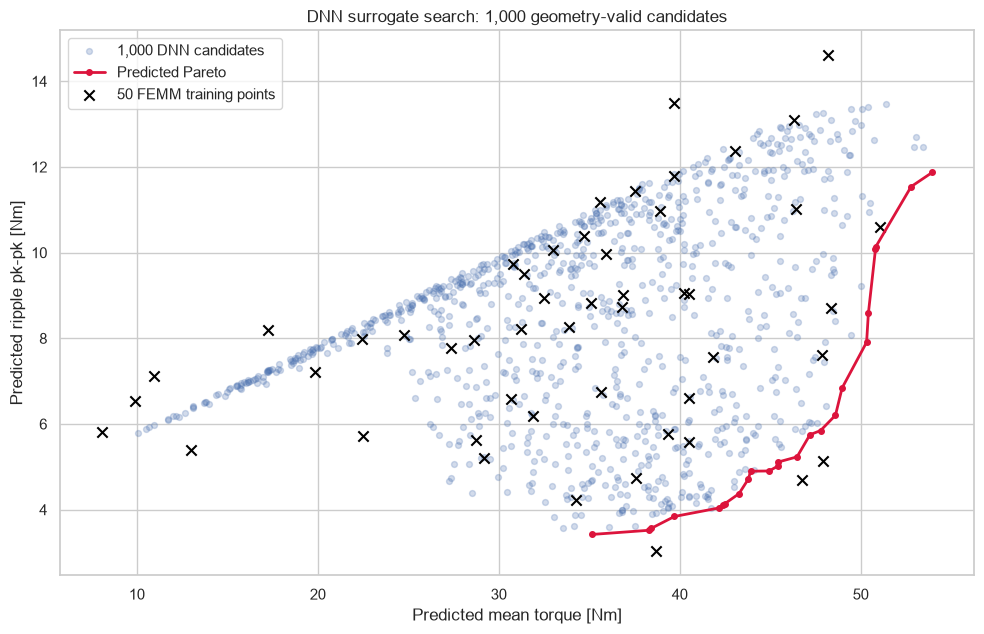

예측 파레토 중 균형점 상위 20개


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,tip_gap_mm,magnet_center_offset_deg,outer_bridge_min_mm,adjacent_pole_gap_min_mm,pred_mean_torque_Nm,unc_mean_torque_Nm,pred_ripple_pkpk_Nm,unc_ripple_pkpk_Nm,conservative_mean_Nm,conservative_ripple_Nm
candidate,,,,,,,,,,,,,
625,4.8869,16.6191,81.2154,0.6075,24.5450,3.5520,1.0128,48.6037,0.2491,6.2029,0.0910,48.3546,6.2939
361,5.1202,16.3322,80.0992,1.6464,25.6308,3.3641,0.5316,47.7800,0.2648,5.8458,0.0603,47.5152,5.9061
708,4.4685,16.6950,81.2796,1.3425,25.8001,3.6047,0.4080,46.4801,0.2699,5.2315,0.0642,46.2102,5.2957
482,5.4560,15.6676,84.3098,1.1261,24.0616,4.0152,0.8492,47.1951,0.2398,5.7488,0.0804,46.9553,5.8292
636,4.7088,16.7821,74.6008,1.6123,25.7184,2.7954,1.7955,48.9714,0.2476,6.8402,0.0780,48.7237,6.9182
419,4.5769,16.1969,82.8395,1.5389,25.4357,3.9304,0.5316,45.4275,0.2280,5.0188,0.0645,45.1994,5.0832
587,4.3551,16.2881,83.6441,0.8665,24.5799,4.1381,1.0347,45.4411,0.1895,5.1118,0.0624,45.2516,5.1742
921,4.4763,16.2145,81.4141,2.0557,26.1795,3.7619,0.4005,44.9383,0.2365,4.9023,0.0632,44.7018,4.9656
541,4.0221,16.0545,86.0357,0.5782,23.8747,4.6624,1.3857,43.7927,0.1801,4.7154,0.0615,43.6127,4.7770


In [12]:
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(candidates.loc[~candidates.predicted_pareto, "pred_mean_torque_Nm"],
           candidates.loc[~candidates.predicted_pareto, "pred_ripple_pkpk_Nm"],
           s=18, alpha=0.25, label="1,000 DNN candidates")
front = pred_pareto.sort_values("pred_mean_torque_Nm")
ax.plot(front["pred_mean_torque_Nm"], front["pred_ripple_pkpk_Nm"],
        "-o", color="crimson", ms=4, lw=2, label="Predicted Pareto")
ax.scatter(df["loaded_torque_mean_Nm"], df["loaded_torque_pkpk_Nm"],
           marker="x", s=55, color="black", label="50 FEMM training points")
ax.set(xlabel="Predicted mean torque [Nm]",
       ylabel="Predicted ripple pk-pk [Nm]",
       title="DNN surrogate search: 1,000 geometry-valid candidates")
ax.legend()
plt.tight_layout()
plt.show()

# 이상점에 치우치지 않는 파레토 균형점: 예측 파레토 내부에서 ideal까지 정규화 거리
for col in ["pred_mean_torque_Nm", "pred_ripple_pkpk_Nm"]:
    span = front[col].max() - front[col].min()
    if col == "pred_mean_torque_Nm":
        front[col + "_loss"] = (front[col].max() - front[col]) / span
    else:
        front[col + "_loss"] = (front[col] - front[col].min()) / span
front["ideal_distance"] = np.hypot(
    front["pred_mean_torque_Nm_loss"],
    front["pred_ripple_pkpk_Nm_loss"],
)

result_cols = [
    "candidate", *factors,
    "magnet_center_offset_deg", "outer_bridge_min_mm", "adjacent_pole_gap_min_mm",
    "pred_mean_torque_Nm", "unc_mean_torque_Nm",
    "pred_ripple_pkpk_Nm", "unc_ripple_pkpk_Nm",
    "conservative_mean_Nm", "conservative_ripple_Nm",
]
print("예측 파레토 중 균형점 상위 20개")
display(front.sort_values("ideal_distance").set_index("candidate")[result_cols[1:]].head(20))

## 4. 후보별 예측과 불확실성

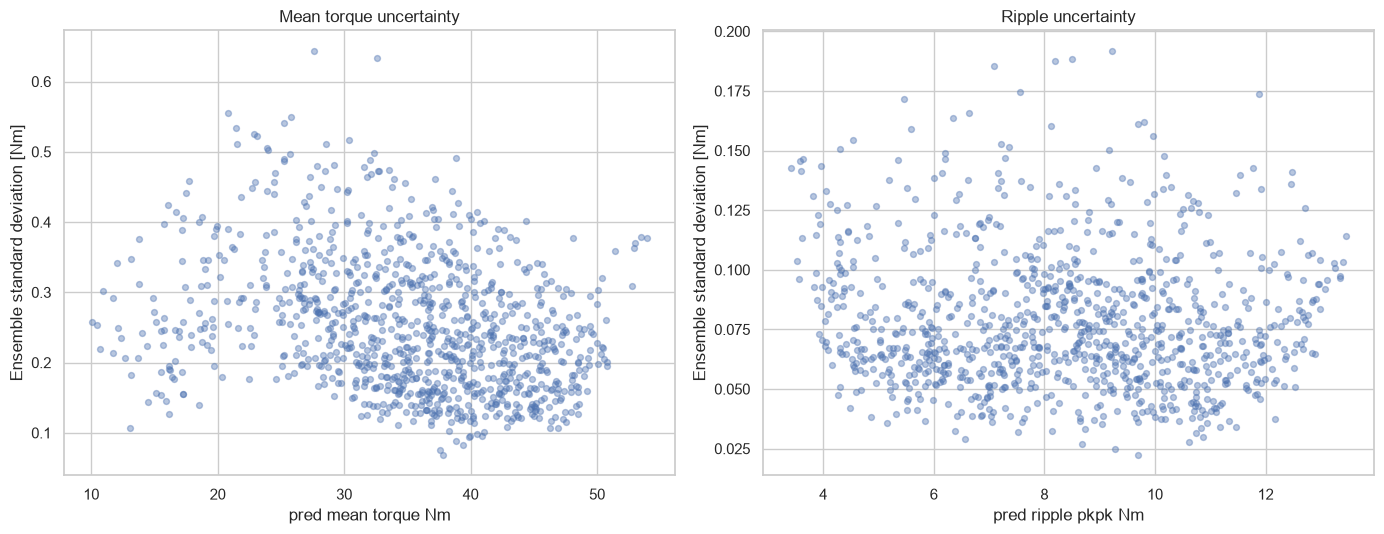

Saved: c:\Users\139\Documents\pyFEMM 2\axis_shortedge_dnn_candidates_1000.csv
Saved: c:\Users\139\Documents\pyFEMM 2\axis_shortedge_dnn_predicted_pareto.csv


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, xcol, ycol, title in [
    (axes[0], "pred_mean_torque_Nm", "unc_mean_torque_Nm", "Mean torque uncertainty"),
    (axes[1], "pred_ripple_pkpk_Nm", "unc_ripple_pkpk_Nm", "Ripple uncertainty"),
]:
    ax.scatter(candidates[xcol], candidates[ycol], s=18, alpha=0.4)
    ax.set(xlabel=xcol.replace("_", " "), ylabel="Ensemble standard deviation [Nm]",
           title=title)
plt.tight_layout()
plt.show()

candidate_csv = ROOT / "axis_shortedge_dnn_candidates_1000.csv"
pareto_csv = ROOT / "axis_shortedge_dnn_predicted_pareto.csv"
candidates.to_csv(candidate_csv, index=False)
front.sort_values("ideal_distance").to_csv(pareto_csv, index=False)
print(f"Saved: {candidate_csv}")
print(f"Saved: {pareto_csv}")

## 5. 결과를 사용할 때의 기준

1. 교차검증 `R²`가 낮거나 RMSE가 크면 DNN 파레토를 최적해로 해석하지 않는다.
2. 앙상블 표준편차가 큰 후보보다 예측값이 조금 낮아도 불확실성이 작은 후보를 우선한다.
3. 균형점 상위 후보를 서로 너무 가까운 형상끼리 중복 선정하지 않는다.
4. 최종 5–10개 후보는 반드시 FEMM 0.5° 스윕으로 재해석한다.
5. FEMM 검증점이 추가되면 50점 학습자료에 합쳐 surrogate를 다시 학습한다.

## Standardized Research Conclusion
<!-- STANDARDIZED_RESEARCH_CONCLUSION -->

**Research Question.** 싱글레이어에서 평균토크와 낮은 리플을 함께 달성할 수 있는가?

**Answer.** 가능하다. Run 49는 46.76 N·m, 4.69 N·m pk-pk의 균형점이며 최대토크 Run 27은 51.07 N·m이지만 리플이 10.60 N·m다. 평균토크 모델(CV R²≈0.99)은 길이의 영향이 강했고, 리플 모델(CV R²≈0.77)은 V-angle과 상호작용의 영향을 보였다.

**Limitation.** 고정 10 A·commutation 및 2° 회전자 샘플 결과다.

**Next Step.** Run 14·42·49를 미세 회전자각과 commutation sweep으로 재검증한다.